In [2]:
'''Online Purchase Behaviour Classification
This system predicts whether a customer will purchase or not using browsing time, 
clicks,
product views, etc. Data is preprocessed and scaled to improve model learning. Feature
selection removes useless features like duplicate or low-impact behaviour data. Logistic
Regression and KNN are used for classification. Performance is measured using 
accuracy,
precision, recall, and F1-score.'''


'Online Purchase Behaviour Classification\nThis system predicts whether a customer will purchase or not using browsing time, \nclicks,\nproduct views, etc. Data is preprocessed and scaled to improve model learning. Feature\nselection removes useless features like duplicate or low-impact behaviour data. Logistic\nRegression and KNN are used for classification. Performance is measured using \naccuracy,\nprecision, recall, and F1-score.'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

In [4]:
#  Load Dataset
df = pd.read_csv("/Users/mayank/code/pand@s/pbl/raw_dataset.csv")

In [5]:
#  Remove Duplicates 
df = df.drop_duplicates()

#  Handle Missing Values
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].mean())

# Categorical → mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop ID 
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

#  Encode Categorical Data
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Convert boolean to int
df['Revenue'] = df['Revenue'].astype(int)
df['Weekend'] = df['Weekend'].astype(int)


/var/folders/d4/l_lb0t1n7rb86t9py2bks8qw0000gn/T/ipykernel_12448/3325180705.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [6]:
# shows cleaned data 
print("Shape:", df.shape)
# show nummber of NULL values that handled after
print("\nNull values:\n", df.isnull().sum())
# shows data type 
print("\nData types:\n", df.dtypes)


Shape: (2506, 18)

Null values:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Data types:
 Administrative             float64
Administrative_Duration    float64
Informational              float64
Informational_Duration     float64
ProductRelated             float64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                        int64
OperatingSystems           float6

In [7]:
#  Balance Dataset (Undersampling)
df_false = df[df['Revenue'] == 0]
df_true = df[df['Revenue'] == 1]
df_false_sample = df_false.sample(n=len(df_true), random_state=42)
df_balanced = pd.concat([df_false_sample, df_true])

# Shuffle
df_balanced = df_balanced.sample(frac=1, random_state=42)

#  Split Features & Target
X = df_balanced.drop('Revenue', axis=1)
y = df_balanced['Revenue']




In [8]:
#  Train-Test Split (70-30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [9]:
#  Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# MODEL 1: Logistic Regression


lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(" Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Report:\n", classification_report(y_test, y_pred_lr))

 Logistic Regression Results:
Accuracy: 0.7815126050420168
Confusion Matrix:
 [[104  17]
 [ 35  82]]
Report:
               precision    recall  f1-score   support

           0       0.75      0.86      0.80       121
           1       0.83      0.70      0.76       117

    accuracy                           0.78       238
   macro avg       0.79      0.78      0.78       238
weighted avg       0.79      0.78      0.78       238



In [11]:
#  MODEL 2: KNN


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("\nKNN Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Report:\n", classification_report(y_test, y_pred_knn))


KNN Results:
Accuracy: 0.6974789915966386
Confusion Matrix:
 [[93 28]
 [44 73]]
Report:
               precision    recall  f1-score   support

           0       0.68      0.77      0.72       121
           1       0.72      0.62      0.67       117

    accuracy                           0.70       238
   macro avg       0.70      0.70      0.70       238
weighted avg       0.70      0.70      0.70       238




 Sample Prediction (LR): [1]
 Sample Prediction (KNN): [0]


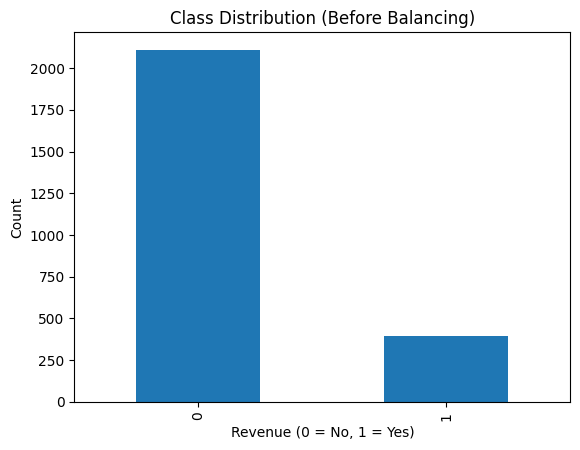

In [12]:
# Prediction on New Data
sample = X_test[0].reshape(1, -1)

print("\n Sample Prediction (LR):", lr.predict(sample))
print(" Sample Prediction (KNN):", knn.predict(sample))

# Graph - Class Distribution

df['Revenue'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Before Balancing)")
plt.xlabel("Revenue (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


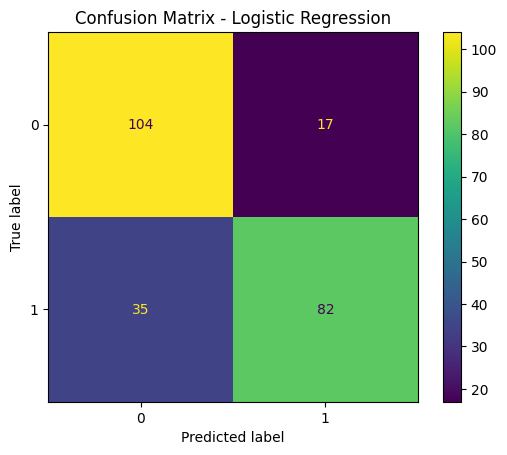

In [13]:
# Graph - Confusion Matrix (Logistic Regression)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

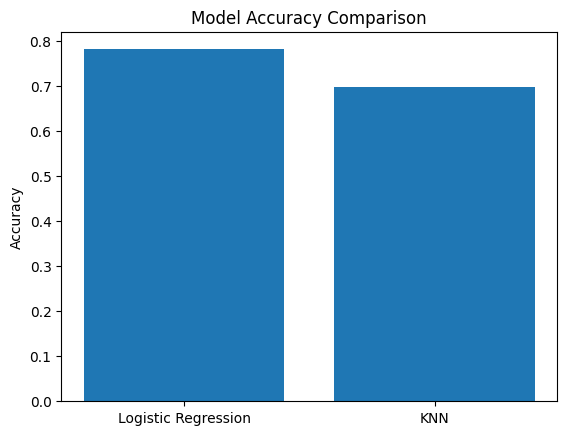

In [14]:
# Graph - Accuracy Comparison 
models = ['Logistic Regression', 'KNN']
accuracies = [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_knn)]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


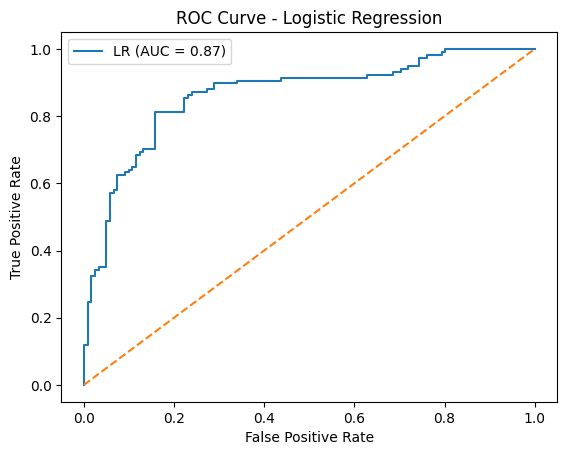

In [15]:

# graph - ROC(Receiver Operating Characteristic Curve)

# Get probabilities
y_prob = lr.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f"LR (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()